In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from amoc_analysis import data, plotting
from amocatlas import read
import scipy.signal as signal
from spectra_filtering import analysis, spectra, filters# sonst amocatlas.spectra_filtering


In [2]:
fig_path = "../figures/"

In [3]:
ds = read.mocha()
MOC = ds["MOC"]
MHT = ds["MHT"]

Loading 1 MOCHA 26°N dataset(s):
  0. Johns_2023_mht_data_2020_ERA5.zip: No description available



/Users/jakob/Desktop/SS2026/DataAnalysis/.venv/lib/python3.13/site-packages/amocatlas/reader_utils.py:80: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(file_path, **kwargs)


In [4]:
stats = analysis.summary_stats(MHT.values)

In [5]:
stats

{'n': 12202,
 'n_missing': np.int64(0),
 'mean': np.float64(1.193355876604808),
 'std': np.float64(0.37629032465293605),
 'median': np.float64(1.2057568424411955),
 'min': np.float64(-0.6388144897809898),
 'max': np.float64(2.5223797350663735),
 'range': np.float64(3.161194224847363)}

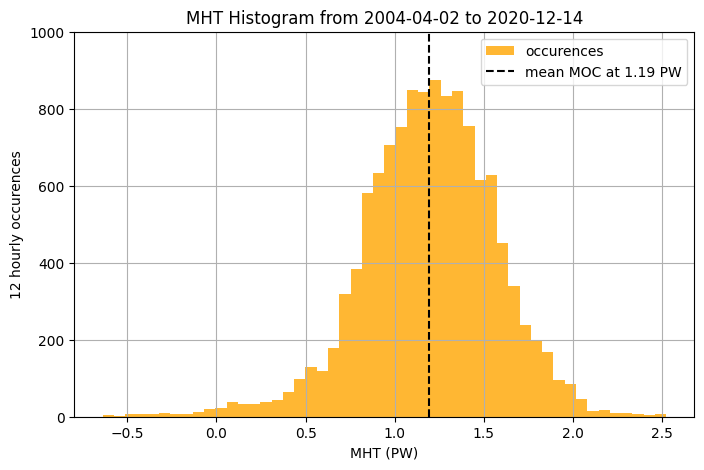

In [6]:
plt.figure(figsize=[8,5])
plt.hist(MHT, bins = 50, alpha = 0.8, color = "orange", label = "occurences")
plt.ylabel("12 hourly occurences")
plt.xlabel("MHT (PW)")
plt.vlines(stats["mean"], 0 ,1000, ls = "--", color = "k", label = f"mean MOC at {stats["mean"]:.2f} PW")
plt.ylim(0,1000)
plt.legend()
plt.grid()
plt.title(f"MHT Histogram from {str(MHT["TIME"].isel(TIME = 0).values)[:10]} to {str(MHT["TIME"].isel(TIME = -1).values)[:10]}")
plt.savefig(fig_path + "MHT_histogram.pdf")

In [21]:
lowpass_180day = filters.tukey_lowpass(MHT, window = 360)

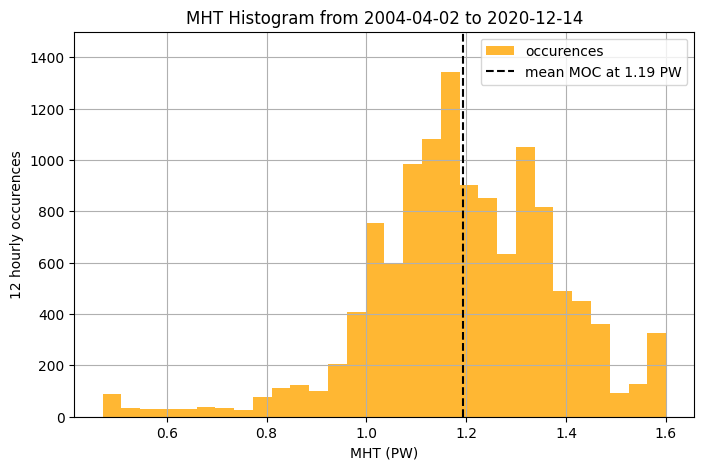

In [26]:
plt.figure(figsize=[8,5])
plt.hist(lowpass_180day, bins = 30, alpha = 0.8, color = "orange", label = "occurences")
plt.ylabel("12 hourly occurences")
plt.xlabel("MHT (PW)")
plt.vlines(stats["mean"], 0 ,1500, ls = "--", color = "k", label = f"mean MOC at {stats["mean"]:.2f} PW")
plt.ylim(0,1500)
plt.legend()
plt.grid()
plt.title(f"MHT Histogram from {str(MHT["TIME"].isel(TIME = 0).values)[:10]} to {str(MHT["TIME"].isel(TIME = -1).values)[:10]}")
plt.savefig(fig_path + "MHT_filtered_histogram.pdf")

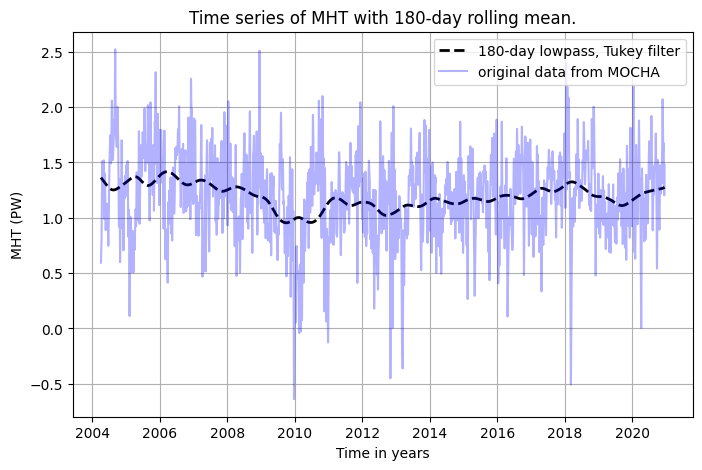

In [ ]:
plt.figure(figsize=[8,5])
plt.plot(MHT["TIME"],lowpass_180day,color = "k", ls = "--", lw = 2, label = "180-day lowpass, Tukey filter")
MHT.plot(alpha = 0.3, color ="blue", label = "original data from MOCHA")
plt.xlabel("Time in years")
plt.ylabel("MHT (PW)")
plt.title("Time series of MHT with 180-day rolling mean.")
plt.grid()
plt.legend()
plt.savefig(fig_path + "180day_lowpass.pdf")